**Import libraries**

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading datasets
train_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/LHL-LLM/data/train_df.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/LHL-LLM/data/test_df.csv')

In [ ]:
# Drop unnecessary columns
test_df = test_df.drop(['text_length'], axis = 1)
train_df = train_df.drop(['text_length'], axis = 1)

**TF-IDF (Term Frequency-Inverse Document Frequency)**

In [ ]:
# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']

# Transform the test data
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

In [ ]:
# Number of features in the TF-IDF representation
num_features = len(vectorizer.vocabulary_)
print("Number of features after TF-IDF:", num_features)

Number of features after TF-IDF: 5000


**Build Model**

I have chosen SVM for the sentiment analysis because it has great ability to handle high-dimensional spaces, which is common in NLP. Additionally, with linear kernel SVM is less prone to overfitting in high-dimensional datasets.

In [ ]:
# Initialize the SVM classifier
svm_model = SVC(kernel = 'linear')

# Train the model
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
# Make Predictions on the Test Set
y_pred = svm_model.predict(X_test)

**Evaluate the model**

Accuracy: 0.87
Precision: 0.87
Recall: 0.87
F1 Score: 0.87
              precision    recall  f1-score   support

           0       0.87      0.88      0.87     12500
           1       0.88      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



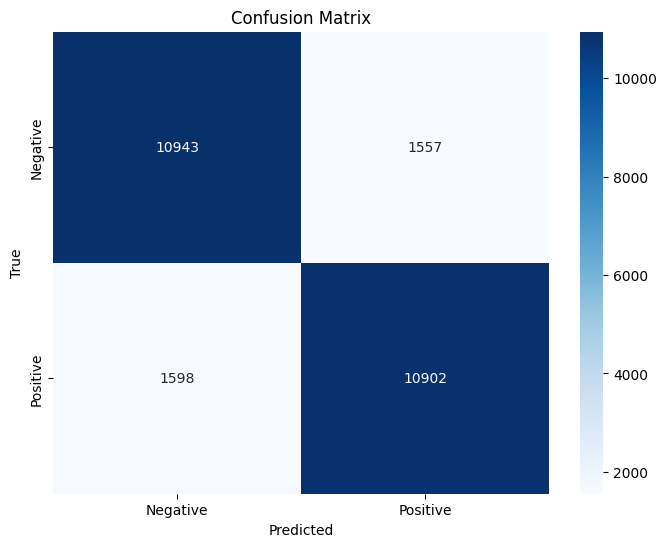

In [ ]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Print classification report
print(classification_report(y_test, y_pred))

# Print confusion matrix
confusion_mtx = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Results analysis**

Accuracy: 0.87 - This means that the model correctly classified 87% of the test samples, which makes it a solid sentiment classifier model.

Overall, the above metrics suggest that the SVM model performs reliably for sentiment analysis, with balanced and high precision and recall across both sentiment classes. While the performance is strong, it would be great to  consider hyperparameter tuning or trying different classifiers, to see if it is possible to get even better results. However, with an accuracy of 87%, this model is already in a good position for sentiment classification tasks.

In [ ]:
# Save the model
import joblib
joblib.dump(svm_model, 'svm.joblib')

['svm.joblib']